# Pertemuan 3 — Data Cleaning

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [18]:
NAMA      = "Novan Frido Saputro"
NIM       = "240401010119"
PRODI     = "Informatika"
ANGKATAN  = 2024
PERTEMUAN = 3

print("=" * 55)
print("  Pengantar Data Science")
print(f"  Pertemuan {PERTEMUAN} — Data Cleaning")
print("=" * 55)
print(f"  Nama     : {NAMA}")
print(f"  NIM      : {NIM}")
print(f"  Prodi    : {PRODI}")
print("=" * 55)

  Pengantar Data Science
  Pertemuan 3 — Data Cleaning
  Nama     : Novan Frido Saputro
  NIM      : 240401010119
  Prodi    : Informatika


In [19]:
!pip install missingno --quiet

print("✅ Semua library siap!")

✅ Semua library siap!


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import missingno as msno
import requests
import json
import warnings

from scipy import stats
from scipy.stats.mstats import winsorize
from pandas import json_normalize

warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Semua library berhasil diimport!
   pandas  : 2.2.2
   numpy   : 2.0.2


In [21]:
df = pd.read_csv('housing_dirty.csv')
df_asli = df.copy()

print(f"✅ Dataset berhasil dimuat!")
print(f"Shape: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Kolom: {list(df.columns)}")

✅ Dataset berhasil dimuat!
Shape: 130 baris × 7 kolom
Kolom: ['id', 'luas_m2', 'harga_juta', 'kota', 'kamar', 'tahun_bangun', 'kondisi']


  EKSPLORASI AWAL DATASET

--- 5 Baris Pertama ---
   id  luas_m2  harga_juta   kota  kamar  tahun_bangun kondisi
0   1    297.0      1084.0  jogja    2.0          2000    baik
1   2    254.0       761.0  Medan    NaN          1995   Bagus
2   3    249.7       895.0  Depok    NaN          1983    baik
3   4     49.7       178.0    YGY    5.0          2013    baik
4   5    133.4       424.0  Medan    5.0          2004  Sedang

--- Info Kolom & Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory u

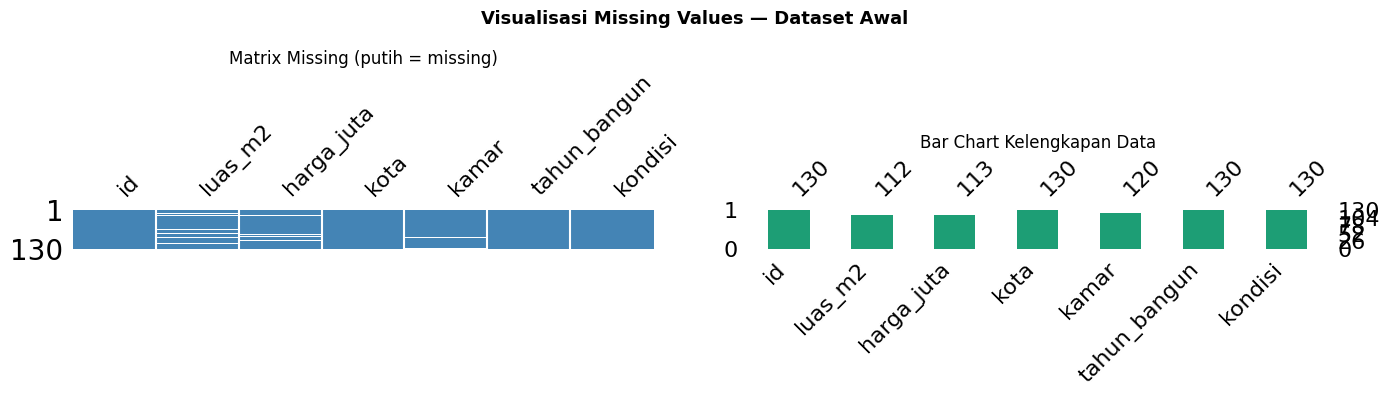

✅ Grafik disimpan: eksplorasi_missing.png


In [22]:
print("=" * 55)
print("  EKSPLORASI AWAL DATASET")
print("=" * 55)

# 5 baris pertama
print("\n--- 5 Baris Pertama ---")
print(df.head())

# Info tipe data
print("\n--- Info Kolom & Tipe Data ---")
print(df.info())

# Statistik deskriptif
print("\n--- Statistik Deskriptif ---")
print(df.describe().round(2))

# Cek missing values
print("\n--- Missing Values per Kolom ---")
missing = df.isnull().sum()
pct     = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

# Cek duplikat
print(f"\n--- Duplikat ---")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Visualisasi pola missing
print("\n📊 Menampilkan visualisasi missing values...")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Visualisasi Missing Values — Dataset Awal", fontsize=13, fontweight='bold')

msno.matrix(df, ax=axes[0], sparkline=False, color=(0.27, 0.52, 0.71))
axes[0].set_title("Matrix Missing (putih = missing)")

msno.bar(df, ax=axes[1], color='#1D9E75')
axes[1].set_title("Bar Chart Kelengkapan Data")

plt.tight_layout()
plt.savefig("eksplorasi_missing.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: eksplorasi_missing.png")

In [23]:
print("=" * 55)
print("  STEP 1 — HAPUS DUPLIKAT")
print("=" * 55)

sebelum = df.shape[0]
df.drop_duplicates(inplace=True)
sesudah = df.shape[0]

print(f"Sebelum : {sebelum} baris")
print(f"Sesudah : {sesudah} baris")
print(f"Dihapus : {sebelum - sesudah} baris duplikat")
print(f"\n✅ Tidak ada duplikat lagi: {df.duplicated().sum() == 0}")

  STEP 1 — HAPUS DUPLIKAT
Sebelum : 130 baris
Sesudah : 130 baris
Dihapus : 0 baris duplikat

✅ Tidak ada duplikat lagi: True


In [24]:
print("=" * 55)
print("  STEP 2 — NORMALISASI STRING")
print("=" * 55)

# Sebelum normalisasi
print("Nilai unik 'kota' SEBELUM normalisasi:")
print(df['kota'].value_counts().to_string())

# Normalisasi: strip spasi + Title Case (huruf kapital di awal kata)
df['kota']    = df['kota'].str.strip().str.title()

# Normalisasi: strip spasi + semua huruf kecil
df['kondisi'] = df['kondisi'].str.strip().str.lower()

print("\nNilai unik 'kota' SETELAH normalisasi:")
print(df['kota'].value_counts().to_string())

print("\nNilai unik 'kondisi' SETELAH normalisasi:")
print(df['kondisi'].value_counts().to_string())

print("\n✅ Normalisasi string selesai!")

  STEP 2 — NORMALISASI STRING
Nilai unik 'kota' SEBELUM normalisasi:
kota
Bandung       14
Medan         13
Makassar      12
Yogyakarta    10
Jakarta        9
Depok          7
Surabaya       7
Semarang       6
medan          5
jogja          5
yogyakarta     4
makassar       4
Jogja          3
semarang       3
YGY            3
mdn            2
sby            2
dpk            2
jakarta        2
DEPOK          2
Smg            2
MAKASSAR       2
surabaya       2
Mksr           2
JAKARTA        1
Bdg            1
depok          1
bandung        1
Bandung        1
SURABAYA       1
 Jakarta       1

Nilai unik 'kota' SETELAH normalisasi:
kota
Medan         18
Makassar      18
Bandung       16
Yogyakarta    14
Jakarta       13
Depok         10
Surabaya      10
Semarang       9
Jogja          8
Ygy            3
Sby            2
Dpk            2
Mdn            2
Smg            2
Mksr           2
Bdg            1

Nilai unik 'kondisi' SETELAH normalisasi:
kondisi
baik              58
sedang    

In [25]:
print("=" * 55)
print("  STEP 3 — IMPUTASI MISSING VALUES")
print("=" * 55)

print("Missing SEBELUM imputasi:")
print(df[['luas_m2','harga_juta','kamar']].isnull().sum())

# Hitung nilai untuk imputasi
median_luas   = df['luas_m2'].median()
median_harga  = df['harga_juta'].median()
modus_kamar   = df['kamar'].mode()[0]

print(f"\nNilai imputasi:")
print(f"  luas_m2    → median = {median_luas:.1f} m²")
print(f"  harga_juta → median = {median_harga:.1f} juta")
print(f"  kamar      → modus  = {int(modus_kamar)} kamar")

# Lakukan imputasi
df['luas_m2']    = df['luas_m2'].fillna(median_luas)
df['harga_juta'] = df['harga_juta'].fillna(median_harga)
df['kamar']      = df['kamar'].fillna(modus_kamar)

print("\nMissing SETELAH imputasi:")
print(df[['luas_m2','harga_juta','kamar']].isnull().sum())
print("\n✅ Imputasi selesai — tidak ada missing values lagi!")

  STEP 3 — IMPUTASI MISSING VALUES
Missing SEBELUM imputasi:
luas_m2       18
harga_juta    17
kamar         10
dtype: int64

Nilai imputasi:
  luas_m2    → median = 193.8 m²
  harga_juta → median = 655.0 juta
  kamar      → modus  = 1 kamar

Missing SETELAH imputasi:
luas_m2       0
harga_juta    0
kamar         0
dtype: int64

✅ Imputasi selesai — tidak ada missing values lagi!


In [26]:
print("=" * 55)
print("  STEP 4 — DETEKSI & TANGANI OUTLIER")
print("=" * 55)

def deteksi_outlier_iqr(df, kolom):
    """Hitung batas IQR dan kembalikan info outlier."""
    Q1    = df[kolom].quantile(0.25)
    Q3    = df[kolom].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask_out = (df[kolom] < lower) | (df[kolom] > upper)
    return lower, upper, mask_out

kolom_cek = ['harga_juta', 'luas_m2', 'tahun_bangun']

print(f"{'Kolom':<15} {'Batas Bawah':>12} {'Batas Atas':>12} {'Outlier':>8}")
print("-" * 52)

for col in kolom_cek:
    lower, upper, mask = deteksi_outlier_iqr(df, col)
    n_out = mask.sum()
    print(f"{col:<15} {lower:>12.1f} {upper:>12.1f} {n_out:>8} baris")

    # Tangani: clip nilai ke batas (Winsorization manual)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\n✅ Outlier ditangani dengan metode capping (clip ke batas IQR)")

# Verifikasi: cek ulang setelah capping
print("\nVerifikasi setelah capping:")
for col in kolom_cek:
    lower, upper, mask = deteksi_outlier_iqr(df, col)
    print(f"  {col}: {mask.sum()} outlier tersisa")

  STEP 4 — DETEKSI & TANGANI OUTLIER
Kolom            Batas Bawah   Batas Atas  Outlier
----------------------------------------------------
harga_juta            -422.8       1719.2        3 baris
luas_m2               -145.2        513.0        1 baris
tahun_bangun          1960.5       2042.5        3 baris

✅ Outlier ditangani dengan metode capping (clip ke batas IQR)

Verifikasi setelah capping:
  harga_juta: 0 outlier tersisa
  luas_m2: 0 outlier tersisa
  tahun_bangun: 0 outlier tersisa


📊 Membuat visualisasi perbandingan...


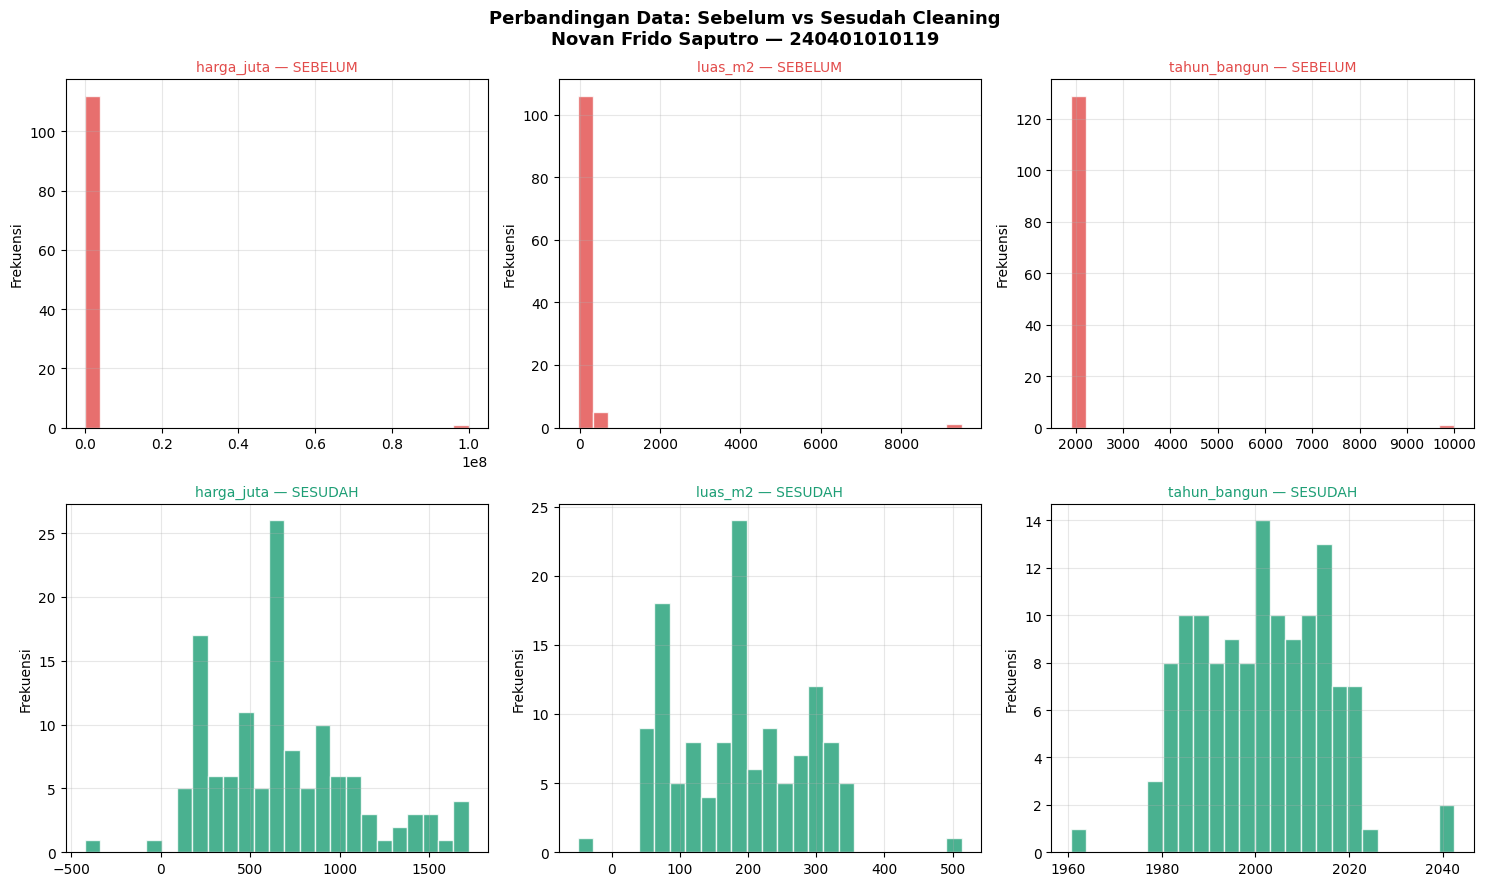

✅ Grafik disimpan: perbandingan_cleaning.png


In [27]:
print("📊 Membuat visualisasi perbandingan...")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f"Perbandingan Data: Sebelum vs Sesudah Cleaning\n{NAMA} — {NIM}",
             fontsize=13, fontweight='bold')

kolom_plot = ['harga_juta', 'luas_m2', 'tahun_bangun']
warna_asli  = '#E24B4A'
warna_bersih = '#1D9E75'

for i, col in enumerate(kolom_plot):
    # Baris atas: sebelum
    ax_atas = axes[0][i]
    data_asli = df_asli[col].dropna()
    ax_atas.hist(data_asli, bins=25, color=warna_asli, alpha=0.8, edgecolor='white')
    ax_atas.set_title(f"{col} — SEBELUM", fontsize=10, color=warna_asli)
    ax_atas.set_ylabel("Frekuensi")
    ax_atas.grid(True, alpha=0.3)

    # Baris bawah: sesudah
    ax_bawah = axes[1][i]
    ax_bawah.hist(df[col], bins=25, color=warna_bersih, alpha=0.8, edgecolor='white')
    ax_bawah.set_title(f"{col} — SESUDAH", fontsize=10, color=warna_bersih)
    ax_bawah.set_ylabel("Frekuensi")
    ax_bawah.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("perbandingan_cleaning.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: perbandingan_cleaning.png")

In [28]:
print("=" * 55)
print("  STEP 5 — VALIDASI AKHIR")
print("=" * 55)

total_missing  = df.isnull().sum().sum()
total_duplikat = df.duplicated().sum()

print(f"Total missing values : {total_missing}")
print(f"Total duplikat       : {total_duplikat}")
print(f"Shape akhir          : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Shape awal           : {df_asli.shape[0]} baris × {df_asli.shape[1]} kolom")

# Assert = otomatis error kalau syarat tidak terpenuhi
try:
    assert total_missing  == 0, "❌ Masih ada missing values!"
    assert total_duplikat == 0, "❌ Masih ada duplikat!"
    print("\n✅✅ VALIDASI LULUS — Dataset sudah bersih dan siap dipakai!")
except AssertionError as e:
    print(f"\n⚠️  {e}")

# Ekspor dataset bersih
df.to_csv('housing_clean.csv', index=False)
print("💾 Dataset bersih disimpan: housing_clean.csv")

  STEP 5 — VALIDASI AKHIR
Total missing values : 0
Total duplikat       : 0
Shape akhir          : 130 baris × 7 kolom
Shape awal           : 130 baris × 7 kolom

✅✅ VALIDASI LULUS — Dataset sudah bersih dan siap dipakai!
💾 Dataset bersih disimpan: housing_clean.csv


In [29]:
print("=" * 55)
print("  STEP 6 — EKSTRAKSI DATA DARI REST API")
print("=" * 55)

URL_API = "https://jsonplaceholder.typicode.com/users"

print(f"📡 Mengakses API: {URL_API}")

try:
    response = requests.get(URL_API, timeout=10)

    # Selalu cek status code dulu
    print(f"Status code: {response.status_code}", end=" ")

    if response.status_code == 200:
        print("(✅ Sukses!)")

        # Parse JSON → DataFrame
        data_api   = response.json()
        df_users   = json_normalize(data_api, sep='_')

        print(f"\nData berhasil diambil: {df_users.shape[0]} user, {df_users.shape[1]} kolom")
        print("\nKolom yang tersedia:")
        print(list(df_users.columns))

        print("\n--- 5 Data User dari API ---")
        kolom_tampil = ['id', 'name', 'email', 'address_city', 'company_name']
        kolom_ada    = [c for c in kolom_tampil if c in df_users.columns]
        print(df_users[kolom_ada].to_string(index=False))

        # Simpan sebagai CSV
        df_users.to_csv('users_api.csv', index=False)
        print("\n💾 Data API disimpan: users_api.csv")

    else:
        print(f"(❌ Gagal — kode {response.status_code})")

except requests.exceptions.ConnectionError:
    print("⚠️  Tidak ada koneksi internet.")
    print("   Membuat data dummy sebagai pengganti...")

    # Data dummy kalau tidak ada internet
    dummy = [
        {'id':1,'name':'Alice','email':'alice@example.com','address_city':'Jakarta','company_name':'TechCo'},
        {'id':2,'name':'Budi' ,'email':'budi@example.com' ,'address_city':'Bandung','company_name':'DataInc'},
        {'id':3,'name':'Citra','email':'citra@example.com','address_city':'Surabaya','company_name':'AILab'},
    ]
    df_users = pd.DataFrame(dummy)
    print(df_users.to_string(index=False))

except Exception as e:
    print(f"⚠️  Error tidak terduga: {e}")

  STEP 6 — EKSTRAKSI DATA DARI REST API
📡 Mengakses API: https://jsonplaceholder.typicode.com/users
Status code: 200 (✅ Sukses!)

Data berhasil diambil: 10 user, 15 kolom

Kolom yang tersedia:
['id', 'name', 'username', 'email', 'phone', 'website', 'address_street', 'address_suite', 'address_city', 'address_zipcode', 'address_geo_lat', 'address_geo_lng', 'company_name', 'company_catchPhrase', 'company_bs']

--- 5 Data User dari API ---
 id                     name                     email   address_city       company_name
  1            Leanne Graham         Sincere@april.biz    Gwenborough    Romaguera-Crona
  2             Ervin Howell         Shanna@melissa.tv    Wisokyburgh       Deckow-Crist
  3         Clementine Bauch        Nathan@yesenia.net  McKenziehaven Romaguera-Jacobson
  4         Patricia Lebsack Julianne.OConner@kory.org    South Elvis      Robel-Corkery
  5         Chelsey Dietrich  Lucio_Hettinger@annie.ca     Roscoeview        Keebler LLC
  6     Mrs. Dennis Schuli

In [31]:
print("\n" + "=" * 55)
print("  RINGKASAN PIPELINE CLEANING PERTEMUAN 3")
print("=" * 55)

ringkasan = [
    ("STEP 0", "Load & Eksplorasi Awal",    "df.info(), isnull(), describe()"),
    ("STEP 1", "Hapus Duplikat",             "drop_duplicates()"),
    ("STEP 2", "Normalisasi String",         "str.strip().str.title() / .lower()"),
    ("STEP 3", "Imputasi Missing Values",    "fillna(median) / fillna(modus)"),
    ("STEP 4", "Tangani Outlier (IQR)",      "clip(lower, upper)"),
    ("STEP 5", "Validasi & Ekspor",          "assert + to_csv()"),
    ("STEP 6", "Ekstraksi API",              "requests.get() + json_normalize()"),
]

print(f"\n{'Step':<8} {'Aktivitas':<30} {'Fungsi Utama'}")
print("-" * 75)
for step, aktivitas, fungsi in ringkasan:
    print(f"{step:<8} {aktivitas:<30} {fungsi}")

print(f"\n📁 File yang dihasilkan:")
print(f"   - housing_clean.csv          (dataset bersih)")
print(f"   - users_api.csv              (data dari API)")
print(f"   - eksplorasi_missing.png     (visualisasi missing)")
print(f"   - perbandingan_cleaning.png  (before vs after)")


  RINGKASAN PIPELINE CLEANING PERTEMUAN 3

Step     Aktivitas                      Fungsi Utama
---------------------------------------------------------------------------
STEP 0   Load & Eksplorasi Awal         df.info(), isnull(), describe()
STEP 1   Hapus Duplikat                 drop_duplicates()
STEP 2   Normalisasi String             str.strip().str.title() / .lower()
STEP 3   Imputasi Missing Values        fillna(median) / fillna(modus)
STEP 4   Tangani Outlier (IQR)          clip(lower, upper)
STEP 5   Validasi & Ekspor              assert + to_csv()
STEP 6   Ekstraksi API                  requests.get() + json_normalize()

📁 File yang dihasilkan:
   - housing_clean.csv          (dataset bersih)
   - users_api.csv              (data dari API)
   - eksplorasi_missing.png     (visualisasi missing)
   - perbandingan_cleaning.png  (before vs after)


## Kesimpulan — Pertemuan 3: Data Cleaning

Sebelum praktikum ini, saya pikir bagian tersulit dari Data Science adalah membangun model. Ternyata saya salah — membersihkan data jauh lebih menyita waktu dan perhatian. Istilah "garbage in, garbage out" baru benar-benar saya pahami setelah merasakan langsung betapa banyak "kotoran" yang bisa bersembunyi di sebuah dataset.

Pipeline yang saya pelajari terasa sangat praktis: dari deteksi duplikat, normalisasi teks yang tidak konsisten, imputasi missing values, hingga penanganan outlier dengan IQR clipping. Yang menarik dari metode clipping adalah kita tidak kehilangan data — nilai ekstrem cukup dipangkas ke batas yang masuk akal, bukan dihapus.

Bagian ekstraksi data dari API juga membuka kemungkinan baru bagi saya. Saya baru sadar bahwa banyak data publik bisa diakses langsung lewat kode tanpa harus download manual. Ke depan saya ingin mengeksplorasi lebih banyak API publik yang bisa dipakai untuk proyek data science.
